In [2]:
import numpy as np
import sys
import os
import time

#CLASS
import classy
import matplotlib.pyplot as plt

In [3]:
w0 = -1.3
Omega_ede = 0.006
h = 0.7

In [5]:
cosmo.compute()

In [13]:
ba = cosmo.get_background()
ba.keys()

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_fld', '(.)w_fld', '(.)rho_ur', '(.)rho_crit', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])

In [61]:
# Fixed parameters
w0 = -0.9
h = 0.7
Omega_ede_values = np.linspace(0.001, 0.009, 10)  # 10 values from 0.001 to 0.009


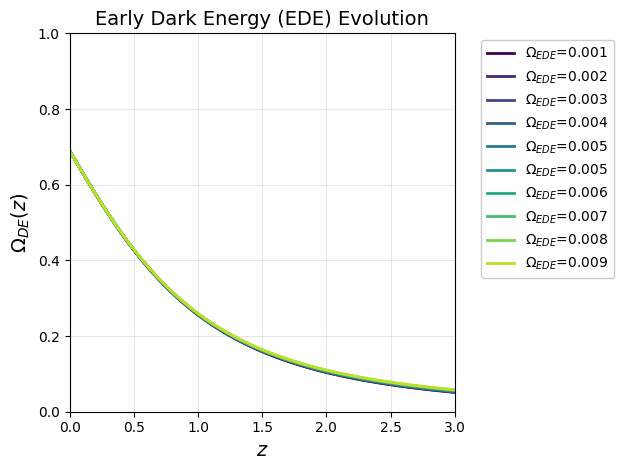

In [36]:
cmap = plt.get_cmap('viridis')
colors = [cmap(i/len(Omega_ede_values)) for i in range(len(Omega_ede_values))]

for i, Omega_ede in enumerate(Omega_ede_values):
    # Initialize CLASS
    cosmo = classy.Class()
    cosmo.set({
        'use_ppf': 'yes',
        'tol_initial_Omega_r': 0.1,
        'fluid_equation_of_state': 'EDE',
        'A_s': 2.100549e-09,
        'n_s': 0.9660499,
        'h': h,
        'w0_fld': w0,
        'Omega_EDE': Omega_ede,
        'Omega_Lambda': 0.0,
        'gauge': 'Newtonian',
        'output': 'tCl mPk',
        'P_k_max_1/Mpc': 50.,
        'z_max_pk': 5.0,
        'k_output_values': '0.5',
        'non linear': 'halofit'
    })
    cosmo.compute()
    
    ba = cosmo.get_background()
    omega_de = ba['(.)rho_fld']/ba['(.)rho_crit']
    
    plt.plot(ba['z'], omega_de,
             color=colors[i],
             lw=2,
             label=f'$\Omega_{{EDE}}$={Omega_ede:.3f}')

plt.xlim(0, 3)
plt.ylim(0, 1.0)  
plt.xlabel('$z$', fontsize=14)
plt.ylabel(r'$\Omega_{DE}(z)$', fontsize=14)
plt.grid(True, alpha=0.3)
plt.title('Early Dark Energy (EDE) Evolution', fontsize=14)

sm = plt.cm.ScalarMappable(cmap=cmap, 
                          norm=plt.Normalize(vmin=min(Omega_ede_values), 
                                           vmax=max(Omega_ede_values)))

plt.legend(fontsize=10, framealpha=1, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

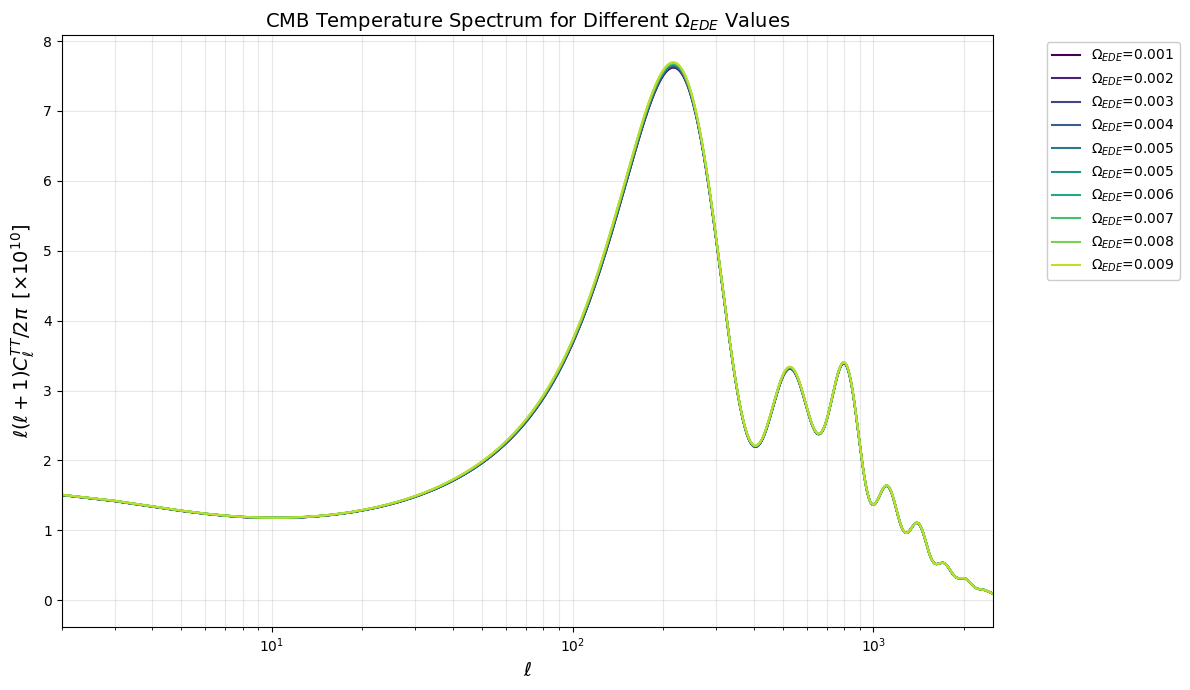

In [63]:
l_max_scalars = 2500
l_max_tensors = 600


cmap = plt.get_cmap('viridis')
colors = [cmap(i/len(Omega_ede_values)) for i in range(len(Omega_ede_values))]


plt.figure(figsize=(12, 7))
plt.xlim(2, 2500)
plt.xlabel(r"$\ell$", fontsize=14)
plt.ylabel(r"$\ell (\ell+1) C_\ell^{TT} / 2 \pi \,\,\, [\times 10^{10}]$", fontsize=14)
plt.title("CMB Temperature Spectrum for Different $\Omega_{EDE}$ Values", fontsize=14)
plt.grid(True, which="both", alpha=0.3)

for i, Omega_ede in enumerate(Omega_ede_values):
    # Common settings with current Omega_ede value
    common_settings = {
        'use_ppf': 'yes',
        'tol_initial_Omega_r': 0.1,
        'fluid_equation_of_state': 'EDE',
        'A_s': 2.100549e-09,
        'n_s': 0.9660499,
        'h': h,
        'w0_fld': w0,
        'Omega_EDE': Omega_ede,
        'Omega_Lambda': 0.0,
        'gauge': 'Newtonian',
        'non linear': 'halofit'
    }
    
    # Initialize CLASS for CMB
    M = classy.Class()
    M.set({
        **common_settings,
        'output': 'tCl,pCl,lCl',
        'modes': 's,t',
        'lensing': 'yes',
        'r': 0.1,
        'n_t': 0,
        'l_max_scalars': l_max_scalars,
        'l_max_tensors': l_max_tensors
    })
    M.compute()
    
    # Get lensed CMB spectrum
    cl_lensed = M.lensed_cl(l_max_scalars)
    ell = cl_lensed['ell']
    factor = 1e10 * ell * (ell + 1) / (2 * np.pi)
    cl_tt = factor * cl_lensed['tt']
    
    # Plot with color gradient
    plt.semilogx(ell, cl_tt,
                color=colors[i],
                lw=1.5,
                label=f'$\Omega_{{EDE}}$={Omega_ede:.3f}')
    
    # Clear CLASS instance for next iteration
    M.struct_cleanup()
    M.empty()

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, 
                         norm=plt.Normalize(vmin=min(Omega_ede_values), 
                         vmax=max(Omega_ede_values)))

plt.legend(fontsize=10, framealpha=1, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [6]:
cosmo.sigma8()

0.879184853027757

In [7]:
z = np.linspace(0.0, 5.0, 50)
krange2 = np.logspace(np.log10(1e-4), np.log10(1e-3), num=40, endpoint=False)
krange3 = np.logspace(np.log10(1e-3), np.log10(1e-2), num=60, endpoint=False)
krange4 = np.logspace(np.log10(1e-2), np.log10(1e-1), num=80, endpoint=False)
krange5 = np.logspace(np.log10(1e-1), np.log10(1), num=100, endpoint=False)
krange6 = np.logspace(np.log10(1), np.log10(10), num=120, endpoint=False)

k = np.concatenate((krange2, krange3, krange4, krange5, krange6))
#Linear DS
P_lin = np.array([[cosmo.pk(ki, zi)*h**3.0 for ki in k*h] for zi in z])

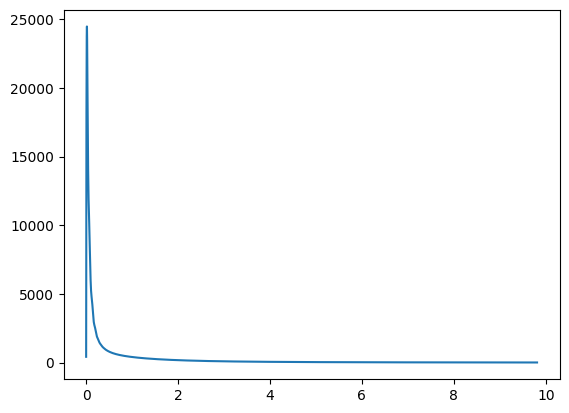

In [10]:
plt.plot(k,P_lin[1])